# SQL Analysis with DuckDB

The rest of this project uses pandas for data processing (see `notebooks/01_solar_forecasting_plant1.ipynb` and `src/dataset.py`). This notebook is a supplementary demonstration of SQL skills on the same dataset, using [DuckDB](https://duckdb.org/) — it is not part of the main pipeline.

DuckDB can query CSV files directly with SQL, so no separate database or ETL step is needed. Each section below covers a SQL pattern that comes up often in analytics work (funnel/cohort analysis, daily KPI tracking, etc.): joins, window functions, CTEs, grouped aggregation, and time bucketing.


In [1]:
# Section 1: Setup
import duckdb
import matplotlib.pyplot as plt

con = duckdb.connect()

GEN_PATH = '../data/raw/Plant_1_Generation_Data.csv'
WEATHER_PATH = '../data/raw/Plant_1_Weather_Sensor_Data.csv'


## 1. Join

Generation data is logged per inverter (22 rows per timestamp), while weather data is logged once per timestamp for the whole plant. To combine them, take the median `DC_POWER` across inverters per timestamp, then join to weather on `DATE_TIME`.

Note the generation file uses `DD-MM-YYYY HH:MM` timestamps and the weather file uses `YYYY-MM-DD HH:MM:SS` — `strptime` parses the generation format explicitly so the join key lines up.


In [2]:
# Section 1: Join generation and weather data
join_query = f"""
WITH gen AS (
    SELECT
        strptime(DATE_TIME, '%d-%m-%Y %H:%M') AS date_time,
        median(DC_POWER) AS dc_power
    FROM read_csv_auto('{GEN_PATH}')
    GROUP BY date_time
)
SELECT gen.date_time, gen.dc_power, w.AMBIENT_TEMPERATURE, w.IRRADIATION
FROM gen
JOIN read_csv_auto('{WEATHER_PATH}') AS w
  ON gen.date_time = w.DATE_TIME
ORDER BY gen.date_time
"""

joined_df = con.sql(join_query).df()
print(f"{len(joined_df):,} joined rows")
joined_df.head()


3,157 joined rows


,date_time,dc_power,AMBIENT_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,0.0,25.184316,0.0
1,2020-05-15 00:15:00,0.0,25.084589,0.0
2,2020-05-15 00:30:00,0.0,24.935753,0.0
3,2020-05-15 00:45:00,0.0,24.846130,0.0
4,2020-05-15 01:00:00,0.0,24.621525,0.0


## 2. Window functions

Two common patterns for daily KPI tracking: day-over-day change (`LAG`) and a rolling average (`AVG(...) OVER (... ROWS BETWEEN ...)`). Here applied to daily energy yield — the same shape of query used for day-over-day revenue or a 7-day rolling active-user count.


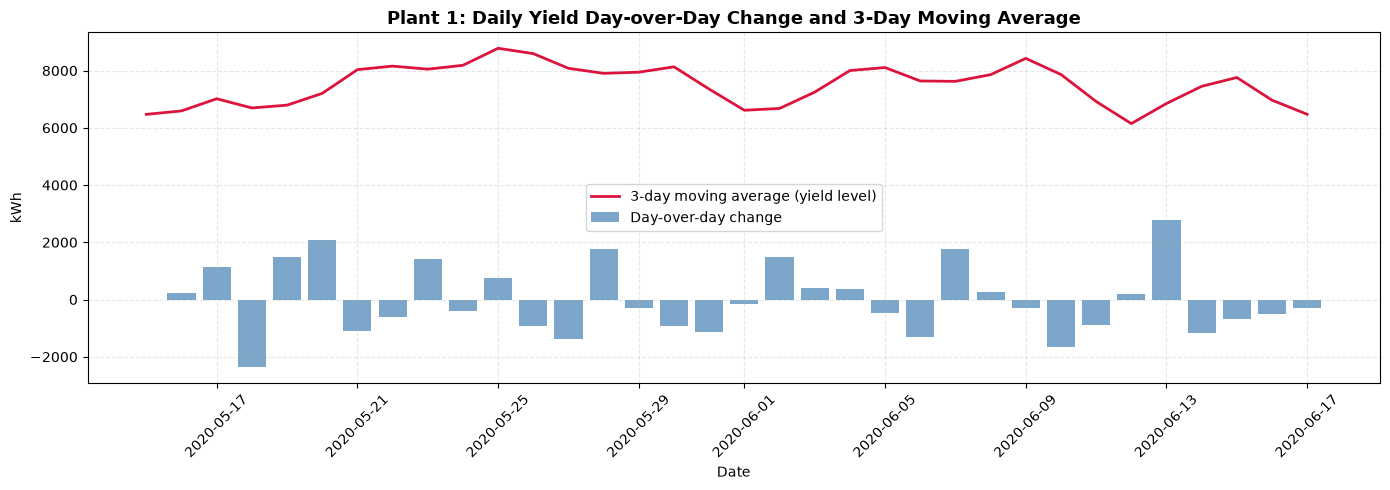

,day,daily_yield,day_over_day_change,moving_avg_3d
0,2020-05-15,6471.0,NaN,6471.000000
1,2020-05-16,6714.0,243.0,6592.500000
2,2020-05-17,7867.0,1153.0,7017.333333
3,2020-05-18,5506.0,-2361.0,6695.666667
4,2020-05-19,7007.0,1501.0,6793.333333
5,2020-05-20,9102.0,2095.0,7205.000000
6,2020-05-21,7993.0,-1109.0,8034.000000
7,2020-05-22,7378.0,-615.0,8157.666667


In [3]:
# Section 2: Day-over-day change and rolling average via window functions
window_query = f"""
WITH daily AS (
    SELECT
        strptime(DATE_TIME, '%d-%m-%Y %H:%M')::DATE AS day,
        max(DAILY_YIELD) AS daily_yield
    FROM read_csv_auto('{GEN_PATH}')
    GROUP BY day
)
SELECT
    day,
    daily_yield,
    daily_yield - LAG(daily_yield) OVER (ORDER BY day) AS day_over_day_change,
    AVG(daily_yield) OVER (ORDER BY day ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) AS moving_avg_3d
FROM daily
ORDER BY day
"""

window_df = con.sql(window_query).df()

plt.figure(figsize=(14, 5))
plt.bar(window_df['day'], window_df['day_over_day_change'], color='steelblue', alpha=0.7, label='Day-over-day change')
plt.plot(window_df['day'], window_df['moving_avg_3d'], color='crimson', lw=2, label='3-day moving average (yield level)')
plt.title('Plant 1: Daily Yield Day-over-Day Change and 3-Day Moving Average', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('kWh')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

window_df.head(8)


## 3. CTE for multi-step analysis

A `WITH` clause lets a multi-step query read top to bottom: parse timestamps, aggregate to daily counts, then filter for days with fewer than the expected 2,112 readings (22 inverters x 96 fifteen-minute intervals) — the same missing-data check done in pandas in `notebooks/01_solar_forecasting_plant1.ipynb`, written here as SQL.


In [4]:
# Section 3: CTE-based missing-data check
cte_query = f"""
WITH parsed AS (
    SELECT
        strptime(DATE_TIME, '%d-%m-%Y %H:%M')::DATE AS day,
        DC_POWER
    FROM read_csv_auto('{GEN_PATH}')
),
daily_counts AS (
    SELECT day, COUNT(*) AS row_count, MAX(DC_POWER) AS dc_max
    FROM parsed
    GROUP BY day
)
SELECT day, row_count, dc_max
FROM daily_counts
WHERE row_count < 2112
ORDER BY day
"""

missing_data_df = con.sql(cte_query).df()
print(f"{len(missing_data_df)} day(s) with fewer than 2,112 readings")
missing_data_df


19 day(s) with fewer than 2,112 readings


,day,row_count,dc_max
0,2020-05-15,1954,12319.14286
1,2020-05-16,1934,11986.57143
2,2020-05-19,1990,11911.50000
3,2020-05-20,1672,13241.14286
4,2020-05-21,1368,14038.28571
5,2020-05-22,2028,14300.28571
6,2020-05-23,1958,13848.00000
7,2020-05-25,2060,13060.71429
8,2020-05-26,2072,13434.42857
9,2020-05-27,2052,13402.87500


## 4. Grouped multi-aggregation

Per-inverter daily statistics (max/min/mean/count) in one query — the SQL equivalent of a `groupby().agg({...})` in pandas, and the same shape as a per-segment daily KPI table.


In [5]:
# Section 4: Per-inverter daily statistics
per_inverter_query = f"""
SELECT
    SOURCE_KEY,
    strptime(DATE_TIME, '%d-%m-%Y %H:%M')::DATE AS day,
    MAX(DC_POWER) AS dc_max,
    MIN(DC_POWER) AS dc_min,
    AVG(DC_POWER) AS dc_mean,
    COUNT(*) AS row_count
FROM read_csv_auto('{GEN_PATH}')
GROUP BY SOURCE_KEY, day
ORDER BY day, SOURCE_KEY
"""

per_inverter_df = con.sql(per_inverter_query).df()
print(f"{len(per_inverter_df):,} rows (22 inverters x 34 days)")
per_inverter_df.head()


748 rows (22 inverters x 34 days)


,SOURCE_KEY,day,dc_max,dc_min,dc_mean,row_count
0,1BY6WEcLGh8j5v7,2020-05-15,10642.75000,0.0,2530.545123,93
1,1IF53ai7Xc0U56Y,2020-05-15,12194.71429,0.0,3082.275085,84
2,3PZuoBAID5Wc2HD,2020-05-15,12158.28571,0.0,3032.929209,84
3,7JYdWkrLSPkdwr4,2020-05-15,11674.75000,0.0,2983.432611,84
4,McdE0feGgRqW7Ca,2020-05-15,12040.57143,0.0,2839.042819,93


## 5. Time bucketing

`CASE WHEN` buckets each reading into peak (11:00-15:00) vs off-peak hours, then aggregates per bucket — the same pattern used to compare conversion rates or engagement by time-of-day segment.


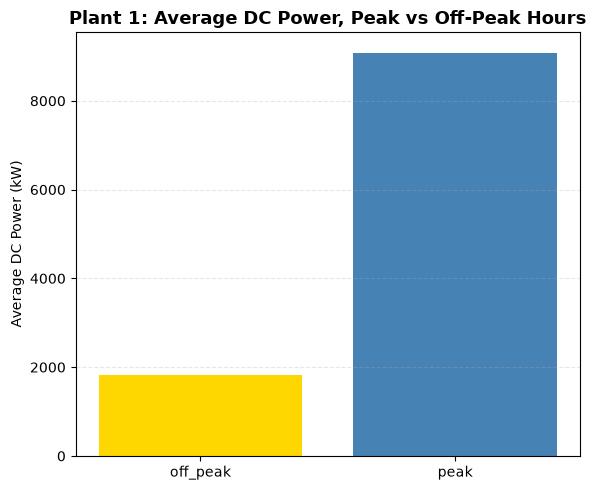

,period,n,avg_dc_power
0,off_peak,56300,1830.752881
1,peak,12478,9088.178614


In [6]:
# Section 5: Peak vs off-peak bucketing
bucket_query = f"""
WITH parsed AS (
    SELECT
        strptime(DATE_TIME, '%d-%m-%Y %H:%M') AS ts,
        DC_POWER
    FROM read_csv_auto('{GEN_PATH}')
)
SELECT
    CASE WHEN strftime(ts, '%H:%M') BETWEEN '11:00' AND '15:00' THEN 'peak' ELSE 'off_peak' END AS period,
    COUNT(*) AS n,
    AVG(DC_POWER) AS avg_dc_power
FROM parsed
GROUP BY period
"""

bucket_df = con.sql(bucket_query).df()

plt.figure(figsize=(6, 5))
plt.bar(bucket_df['period'], bucket_df['avg_dc_power'], color=['gold', 'steelblue'])
plt.title('Plant 1: Average DC Power, Peak vs Off-Peak Hours', fontsize=13, fontweight='bold')
plt.ylabel('Average DC Power (kW)')
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

bucket_df
